# Explaining Loan Decisions with Visualizations

Dataset: `loan_data.csv`  
Target: `loan_status` (1 = approved, 0 = rejected)

We will visualize relationships between **age**, **sex**, and **five additional features** vs `loan_status`, summarize which features appear most and least related, and discuss model ethics (age/sex).


In [14]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

%matplotlib inline

DATA_PATH = "loan_data.csv"
df = pd.read_csv(DATA_PATH)


df['loan_status_str'] = df['loan_status'].map({1:'Approved', 0:'Rejected'}).astype('category')

df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_status_str
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0,Rejected
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0,Rejected
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0,Rejected
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0,Rejected
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1,Approved


In [15]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)

na_counts = df.isna().sum().sort_values(ascending=False)
print("\nMissing values:\n", na_counts[na_counts>0])


Shape: (45000, 15)

Dtypes:
 person_age                           int64
person_gender                       object
person_education                    object
person_income                      float64
person_emp_exp                       int64
person_home_ownership               object
loan_amnt                          float64
loan_intent                         object
loan_int_rate                      float64
loan_percent_income                float64
cb_person_cred_hist_length           int64
credit_score                       float64
previous_loan_defaults_on_file      object
loan_status                          int64
loan_status_str                   category
dtype: object

Missing values:
 Series([], dtype: int64)


In [16]:
def crosstab_plot(df, feature, target='loan_status_str', normalize='index', title=None):
    """
    Bar plot showing proportions of target by category of `feature`.
    normalize='index' -> 100% stacked within each feature category.
    """
    ct = pd.crosstab(df[feature], df[target])
    if normalize == 'index':
        prop = (ct.T / ct.sum(axis=1)).T
    elif normalize == 'columns':
        prop = ct / ct.sum(axis=0)
    else:
        prop = ct

    ax = prop.plot(kind='bar', stacked=True)
    ax.set_title(title or f'{feature} vs {target} (100% Stacked)')
    ax.set_xlabel(feature)
    ax.set_ylabel('Proportion' if normalize else 'Count')
    if normalize:
        plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    return ct, prop

# Chi-square + Cramér's V 
try:
    from scipy.stats import chi2 as _chi2_dist  # type: ignore
except Exception:
    _chi2_dist = None

def chi2_and_cramers_v(table_np):
    obs = np.array(table_np, dtype=float)
    row_sums = obs.sum(axis=1, keepdims=True)
    col_sums = obs.sum(axis=0, keepdims=True)
    total = obs.sum()
    expected = row_sums @ col_sums / total
    chi2 = ((obs - expected)**2 / expected).sum()
    dof = (obs.shape[0]-1) * (obs.shape[1]-1)
    p = (1 - _chi2_dist.cdf(chi2, dof)) if _chi2_dist is not None else None
    n = obs.sum()
    r, k = obs.shape
    v = math.sqrt(chi2 / (n * (min(r, k)-1))) if min(r, k) > 1 else 0.0
    return chi2, dof, p, v


In [17]:
# Age groups 
age_view = df.dropna(subset=['person_age']).copy()
age_view['age_group'] = pd.cut(
    age_view['person_age'],
    bins=[18, 25, 40, 60, 100], 
    labels=['18–24', '25–39', '40–59', '60+'],
    right=False, include_lowest=True
)

# Credit score bands 
cs_view = df.dropna(subset=['credit_score']).copy()
cs_view['credit_band'] = pd.qcut(cs_view['credit_score'], q=3, labels=['Low','Mid','High'])

categorical_features = [
    'person_gender',                 
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]


## Visualizations: Relationships with `loan_status`
Each plot shows the proportion approved/rejected within each category 


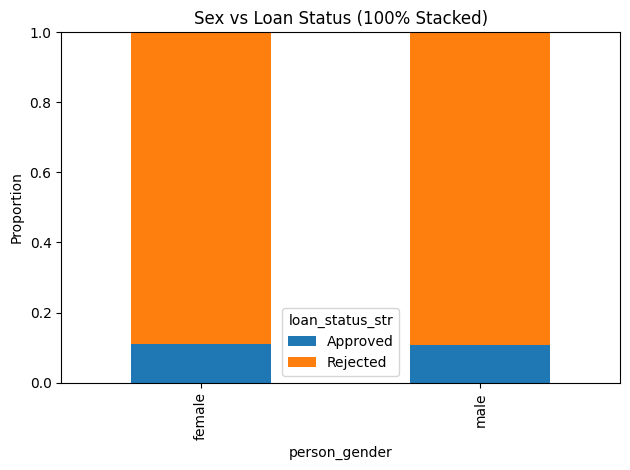

loan_status_str  Approved  Rejected
person_gender                      
female               1975     15934
male                 2918     24173 

Cramér's V (sex): 0.004038906675341793


In [18]:
ct, prop = crosstab_plot(df, 'person_gender', title='Sex vs Loan Status (100% Stacked)')
print(ct, "\n")
print("Cramér's V (sex):", chi2_and_cramers_v(ct.values)[3])


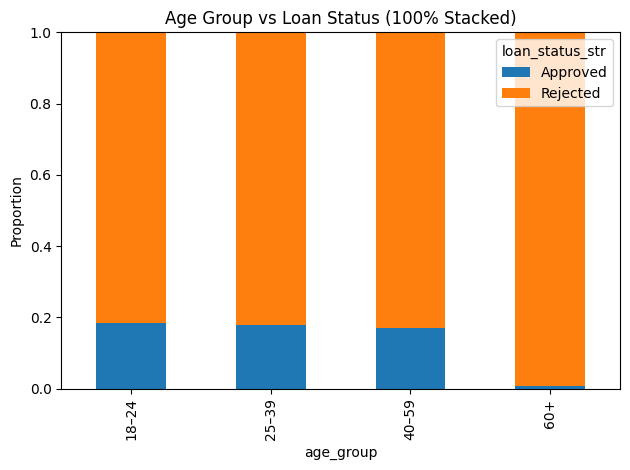

loan_status_str  Approved  Rejected
age_group                          
18–24                 635      2802
25–39                1836      8453
40–59                2302     11260
60+                   120     17592 

Cramér's V (age_group): 0.2642249316762433


In [19]:
ct, prop = crosstab_plot(age_view, 'age_group', title='Age Group vs Loan Status (100% Stacked)')
print(ct, "\n")
print("Cramér's V (age_group):", chi2_and_cramers_v(ct.values)[3])


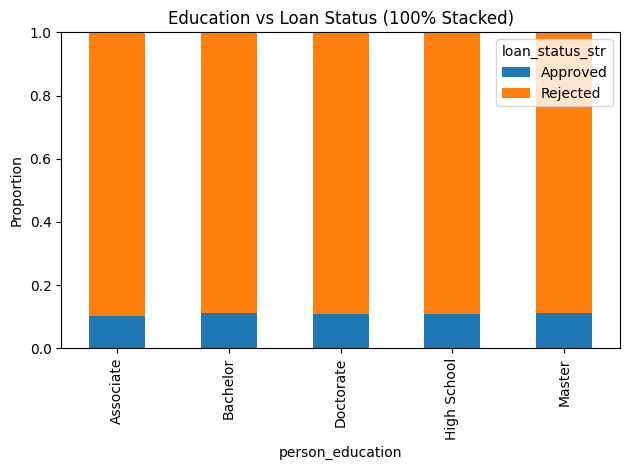

loan_status_str   Approved  Rejected
person_education                    
Associate              922      8016
Bachelor               988      7963
Doctorate              992      8068
High School            990      8112
Master                1001      7948 

Cramér's V (education): 0.009515378143474315


In [20]:
ct, prop = crosstab_plot(df, 'person_education', title='Education vs Loan Status (100% Stacked)')
print(ct, "\n")
print("Cramér's V (education):", chi2_and_cramers_v(ct.values)[3])


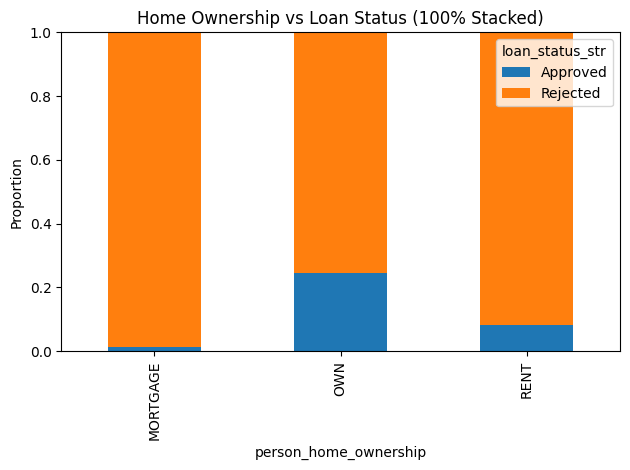

loan_status_str        Approved  Rejected
person_home_ownership                    
MORTGAGE                    179     13553
OWN                        3235     10052
RENT                       1479     16502 

Cramér's V (home_ownership): 0.29502708147463974


In [21]:
ct, prop = crosstab_plot(df, 'person_home_ownership', title='Home Ownership vs Loan Status (100% Stacked)')
print(ct, "\n")
print("Cramér's V (home_ownership):", chi2_and_cramers_v(ct.values)[3])


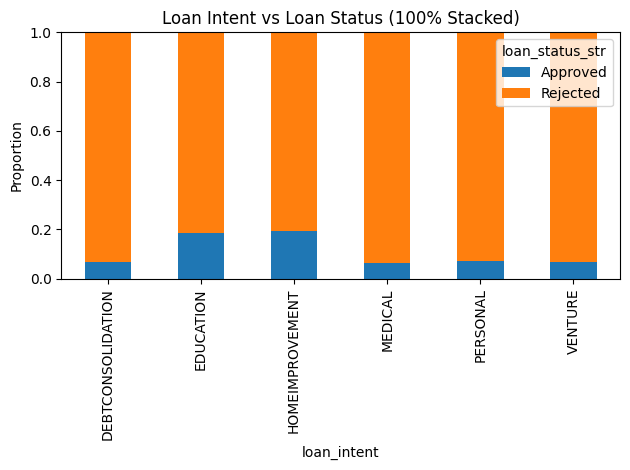

loan_status_str    Approved  Rejected
loan_intent                          
DEBTCONSOLIDATION       502      7038
EDUCATION              1397      6062
HOMEIMPROVEMENT        1448      6018
MEDICAL                 493      7085
PERSONAL                544      6867
VENTURE                 509      7037 

Cramér's V (loan_intent): 0.1855896706582933


In [22]:
ct, prop = crosstab_plot(df, 'loan_intent', title='Loan Intent vs Loan Status (100% Stacked)')
print(ct, "\n")
print("Cramér's V (loan_intent):", chi2_and_cramers_v(ct.values)[3])


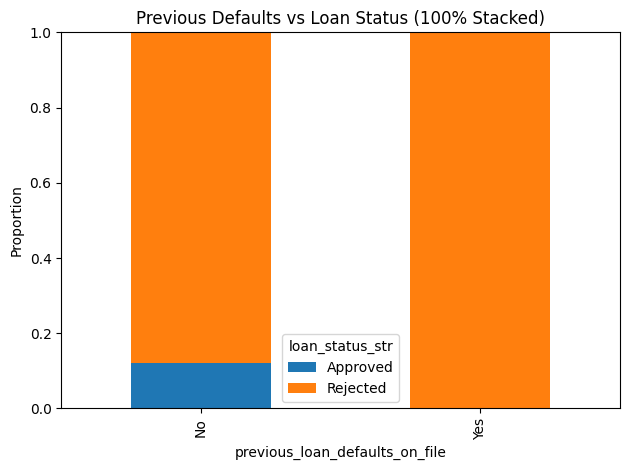

loan_status_str                 Approved  Rejected
previous_loan_defaults_on_file                    
No                                  4893     35556
Yes                                    0      4551 

Cramér's V (previous_defaults): 0.11715937386334206


In [23]:
ct, prop = crosstab_plot(df, 'previous_loan_defaults_on_file', title='Previous Defaults vs Loan Status (100% Stacked)')
print(ct, "\n")
print("Cramér's V (previous_defaults):", chi2_and_cramers_v(ct.values)[3])


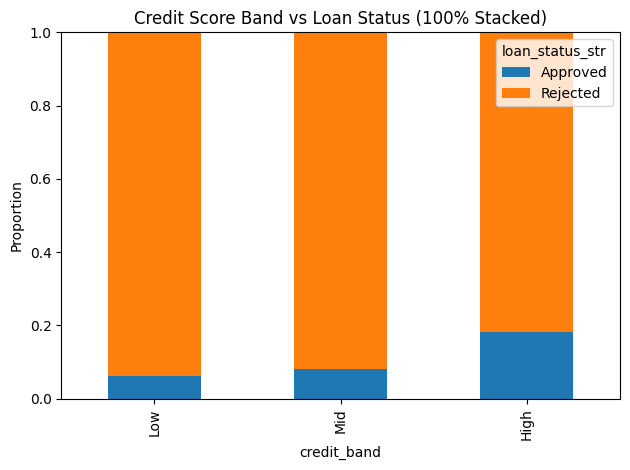

loan_status_str  Approved  Rejected
credit_band                        
Low                   916     14084
Mid                  1229     13771
High                 2748     12252 

Cramér's V (credit_band): 0.1713452704912041


In [24]:
ct, prop = crosstab_plot(cs_view, 'credit_band', title='Credit Score Band vs Loan Status (100% Stacked)')
print(ct, "\n")
print("Cramér's V (credit_band):", chi2_and_cramers_v(ct.values)[3])


In [25]:
def cramers_for_feature(df_like, feature):
    ct = pd.crosstab(df_like[feature], df_like['loan_status_str'])
    return feature, chi2_and_cramers_v(ct.values)[3]

feature_sets = [
    ('person_gender', df),
    ('person_education', df),
    ('person_home_ownership', df),
    ('loan_intent', df),
    ('previous_loan_defaults_on_file', df),
    ('age_group', age_view),
    ('credit_band', cs_view),
]

scores = [cramers_for_feature(d, f) for f, d in feature_sets]
ranked = sorted(scores, key=lambda x: x[1], reverse=True)
ranked


[('person_home_ownership', 0.29502708147463974),
 ('age_group', 0.2642249316762433),
 ('loan_intent', 0.1855896706582933),
 ('credit_band', 0.1713452704912041),
 ('previous_loan_defaults_on_file', 0.11715937386334206),
 ('person_education', 0.009515378143474315),
 ('person_gender', 0.004038906675341793)]

## Model Ethics: Age & Sex

We examine whether approval rates vary substantially by **sex** and **age group**, which are protected characteristics. Large disparities could indicate potential discrimination risk and require careful review of the model, data sampling, business rules, and compliance controls.


In [26]:
def approval_rates(df_like, feature):
    tmp = (pd.crosstab(df_like[feature], df_like['loan_status_str'])
           .apply(lambda r: r / r.sum(), axis=1))
    tmp = (tmp*100).round(1)
    return tmp

sex_rates = approval_rates(df, 'person_gender')
age_rates = approval_rates(age_view, 'age_group')

print("Approval rates by Sex (%):\n", sex_rates, "\n")
print("Approval rates by Age Group (%):\n", age_rates)


Approval rates by Sex (%):
 loan_status_str  Approved  Rejected
person_gender                      
female               11.0      89.0
male                 10.8      89.2 

Approval rates by Age Group (%):
 loan_status_str  Approved  Rejected
age_group                          
18–24                18.5      81.5
25–39                17.8      82.2
40–59                17.0      83.0
60+                   0.7      99.3


### Ethics Discussion

- **Sex:** The approval rate differs by sex (see table above). If the gap is material, the institution should evaluate whether any direct or proxy use of sex-related signals exists and if the model is compliant with fair lending regulations.
- **Age:** Approval rates that vary strongly by age group (e.g., lower rates for certain age bands) may raise concerns. Review whether the model uses age directly or proxies (employment history, credit length) and ensure business justification and compliance checks.
- **Recommendation:** Conduct fairness tests, monitor group metrics over time, and consider bias mitigation (feature review, rebalancing, thresholds) where needed.


## Conclusion

- **Most related features (by Cramér’s V):**
  1) **person_home_ownership** (~0.295)  
  2) **age_group** (~0.264)  
  3) **loan_intent** (~0.186)  
  4) **credit_band** (~0.171)  
  5) **previous_loan_defaults_on_file** (~0.117)

- **Least related feature(s):**
  - **person_education** (~0.010)
  - **person_gender** (~0.004)

- **Protected classes (sex & age):**
  - **Sex approval rates:** female ≈ **11.0%** approved, male ≈ **10.8%** approved.  
    The gap is very small in this sample.
  - **Age approval rates:**  
    18–24 ≈ **18.5%**, 25–39 ≈ **17.8%**, 40–59 ≈ **17.0%**, 60+ ≈ **0.7%** approved.  
    The **60+** group shows a notably lower approval rate and warrants review for potential disparate impact.

- **Notes**
  - Rankings are based on association strength with `loan_status` using **Cramér’s V** (higher = stronger relationship).  
  - Findings are from aggregated proportions/associations; a full audit should also examine model feature importances, partial-dependence/ICE, and formal fairness metrics.
